In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Добавим некоторые данные из pretrain набора

Загрузим полный набор данных

In [5]:
train_part1 = pl.scan_parquet("../ClearData_for_part_4/train_full.parquet")
# train_part1.shape

In [6]:
train_part1.schema

C:\Users\User\AppData\Local\Temp\ipykernel_2652\896344679.py:1: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  train_part1.schema


Schema([('customer_id', Int64),
        ('event_dttm', String),
        ('event_type_nm', Int16),
        ('event_desc', Int16),
        ('channel_indicator_type', Int16),
        ('channel_indicator_sub_type', Int16),
        ('operaton_amt', Float64),
        ('currency_iso_cd', Int16),
        ('mcc_code', Int16),
        ('pos_cd', Int16),
        ('timezone', Int16),
        ('session_id', Float64),
        ('operating_system_type', Int16),
        ('battery', String),
        ('device_system_version', String),
        ('screen_size', String),
        ('developer_tools', Int16),
        ('phone_voip_call_state', Int16),
        ('web_rdp_connection', Int16),
        ('compromised', Int16),
        ('Hour', Int16),
        ('target', Int16)])

In [7]:
pos_class = train_part1.filter(pl.col("target") == 1).collect()
pos_class.shape

(51438, 22)

In [8]:
train_part1 = train_part1.filter(pl.col("target") != 1).collect()
train_part1.shape

(85626402, 22)

In [9]:
neg_class = 13_000_000
train_part1 = train_part1.sample(n=neg_class)

In [10]:
train_part1 = pl.concat([train_part1, pos_class])
train_part1 = train_part1.sample(fraction=1.0, shuffle=True)
train_part1.shape

(13051438, 22)

In [11]:
train_part1 = train_part1.sort("event_dttm")
train_part1 = train_part1.drop("event_dttm")

In [12]:
x = train_part1.drop("target")
y = train_part1["target"]

In [ ]:
X_train = x[:int(0.9*len(x))]
X_test = x[int(0.9*len(x)):]
y_train = y[:int(0.9*len(y))]
y_test = y[int(0.9*len(y)):]

In [ ]:
cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery'
]

for i in cat_features:
    X_train = X_train.with_columns(pl.col(i).fill_null(-1))

for i in cat_features:
    X_test = X_test.with_columns(pl.col(i).fill_null(-1))

In [ ]:
X_train = X_train.drop("customer_id")
X_test = X_test.drop("customer_id")

In [17]:
X_train

event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,pos_cd,timezone,session_id,operating_system_type,battery,device_system_version,screen_size,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,Hour
i16,i16,i16,i16,f64,i16,i16,i16,i16,f64,i16,str,str,str,i16,i16,i16,i16,i16
8,86,4,15,398000.0,0,-1,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,0
7,56,4,15,null,-1,-1,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,0
14,75,6,5,101778.0,0,9,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,0
7,56,3,4,null,-1,-1,-1,33,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,0
14,36,4,15,249450.0,0,-1,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11,48,3,4,null,-1,-1,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,0,-1,3
14,75,0,5,20742.0,0,4,-1,-1,null,-1,"""-1""","""-1""","""-1""",-1,-1,-1,-1,3
7,56,4,15,null,-1,-1,-1,-1,1.2319e14,-1,"""-1""","""14""","""1080x2168""",0,0,-1,0,3


In [18]:
del train_part1, x, y
gc.collect()

79

In [19]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [21]:
cat_features = [
    'device_system_version',
    'screen_size', 'battery']

Попробуем настроить веса меток самостоятельно

In [22]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=200, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9488565499892988
Precision: 0.03500847358088494
Recall: 0.44864957853087906
F1-score: 0.06494893178556642
PR-AUC: 0.061626820729564095

Test metrics:
Accuracy: 0.9569763949418608
Precision: 0.03791050162396247
Recall: 0.4258208350222943
F1-score: 0.0696225602279882
PR-AUC: 0.05348347837389952

Confusion matrix


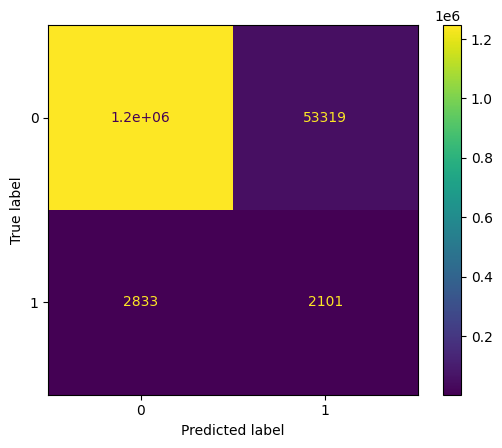

In [23]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [24]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,operaton_amt,21.849586
1,mcc_code,21.533486
2,event_desc,13.660715
3,Hour,8.057443
4,pos_cd,5.776593
5,channel_indicator_type,5.120902
6,channel_indicator_sub_type,3.448966
7,operating_system_type,2.797195
8,session_id,2.596215
9,event_type_nm,2.570325


In [25]:
CatBoost.save_model('../Models/Model_PC_5.1.cbm')

In [26]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=200, depth=6, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9500276427611977
Precision: 0.03603325195463395
Recall: 0.4513160158265956
F1-score: 0.06673810667031287
PR-AUC: 0.0643597375092319

Test metrics:
Accuracy: 0.9579900761908264
Precision: 0.03887173989390215
Recall: 0.4262261856505878
F1-score: 0.07124587109341916
PR-AUC: 0.054977507585939105

Confusion matrix


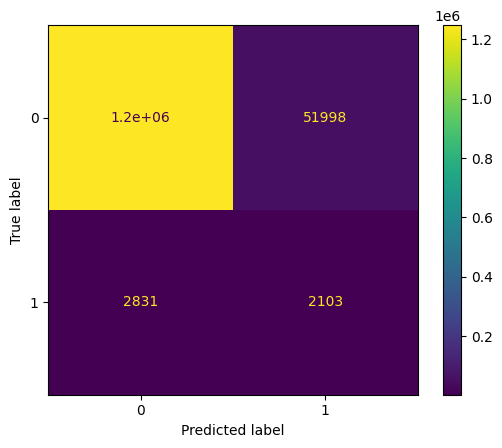

In [27]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [28]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,operaton_amt,22.559056
1,mcc_code,18.422272
2,event_desc,11.994276
3,Hour,9.139440
4,session_id,5.841252
5,channel_indicator_sub_type,5.328871
6,pos_cd,4.815847
7,channel_indicator_type,3.228367
8,timezone,3.164809
9,operating_system_type,3.142953


In [29]:
CatBoost.save_model('../Models/Model_PC_5.2.cbm')

In [30]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=200, depth=7, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 0.9490504834971779
Precision: 0.036044623314269573
Recall: 0.4610571133665921
F1-score: 0.0668620877835815
PR-AUC: 0.06834428003156902

Test metrics:
Accuracy: 0.9567833127992007
Precision: 0.03750628998634174
Recall: 0.42298338062423996
F1-score: 0.06890290204364621
PR-AUC: 0.054245470961481544

Confusion matrix


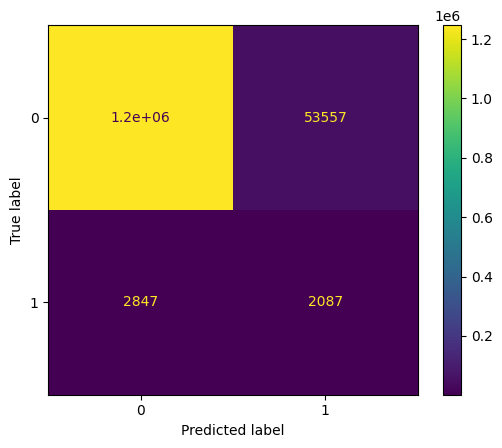

In [31]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [32]:
CatBoost.get_feature_importance(type='PredictionValuesChange', prettified=True)

,Feature Id,Importances
0,operaton_amt,23.303421
1,mcc_code,12.834087
2,event_desc,12.323937
3,Hour,11.817218
4,session_id,7.511165
5,pos_cd,4.803801
6,channel_indicator_type,4.116589
7,channel_indicator_sub_type,3.659721
8,timezone,3.238156
9,device_system_version,2.852925


In [33]:
CatBoost.save_model('../Models/Model_PC_5.3.cbm')